# 01 — Introduction to Machine Learning & Deep Learning

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

In this notebook we build up the core ideas of modern machine learning from scratch:

1. **What is (supervised) machine learning?** — data, ansatz, loss function, training
2. **Linear regression** — the simplest model, solved exactly
3. **Gradient descent** — the workhorse optimization algorithm
4. **Automatic differentiation** — how PyTorch computes gradients for us
5. **Neural networks** — from linear models to universal function approximators
6. **Generalization** — train/test splits, underfitting and overfitting
7. **A full pipeline** — training a classifier end to end

*Prerequisites:* linear algebra, multivariable calculus, basic probability. All code uses [PyTorch](https://pytorch.org) and is intentionally kept simple.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Reproducibility
rng = np.random.default_rng(0)
torch.manual_seed(0)

# A small, colorblind-safe palette used throughout the notebook
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA, YELLOW, MAGENTA]),
    "axes.grid": True, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
})

print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.0+cpu


## 1. What is machine learning?

In **supervised learning** we are given a dataset of $n$ input–output pairs

$$\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n, \qquad (x_i, y_i) \overset{\text{i.i.d.}}{\sim} P,$$

drawn from some unknown probability distribution $P$. The goal is to find a function $f$ that predicts $y$ from $x$ — not just on the data we have seen, but on **new samples from $P$**.

Three ingredients define a learning problem:

| Ingredient | Meaning | Example |
|---|---|---|
| **Ansatz** $\mathcal{F}$ | the set of candidate functions we search over | linear maps, neural networks |
| **Loss** $\ell(\hat y, y)$ | how bad is prediction $\hat y$ when the truth is $y$ | squared error $(\hat y - y)^2$ |
| **Risk** $R(f)$ | expected loss on new data | $R(f) = \mathbb{E}_{(x,y)\sim P}\,[\ell(f(x), y)]$ |

We would like to minimize the risk $R(f)$, but $P$ is unknown — we only have samples. So instead we minimize the **loss function** (the average loss on the training data):

$$\hat f \;=\; \arg\min_{f \in \mathcal{F}} \; L(f), \qquad L(f) = \frac{1}{n} \sum_{i=1}^n \ell\big(f(x_i), y_i\big).$$

**Training** the model means solving this minimization problem, and almost everything in this notebook is an instance of it. Two questions will occupy us:

1. **Optimization:** how do we actually solve this minimization problem? (→ gradient descent, autodiff)
2. **Generalization:** does a small training loss $L(\hat f)$ imply a small true risk $R(\hat f)$? (→ train/test splits, overfitting)

## 2. Warm-up: linear regression

The simplest ansatz: affine functions of a scalar input,

$$f_{w,b}(x) = w x + b, \qquad \mathcal{F} = \{ f_{w,b} : w, b \in \mathbb{R} \},$$

with the **squared loss** $\ell(\hat y, y) = (\hat y - y)^2$. The loss function is the **mean squared error (MSE)**:

$$L(w, b) = \frac{1}{n} \sum_{i=1}^n \big( w x_i + b - y_i \big)^2.$$

Let's generate synthetic data from a "true" line with noise, $y = 2x - 1 + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, 0.5^2)$:

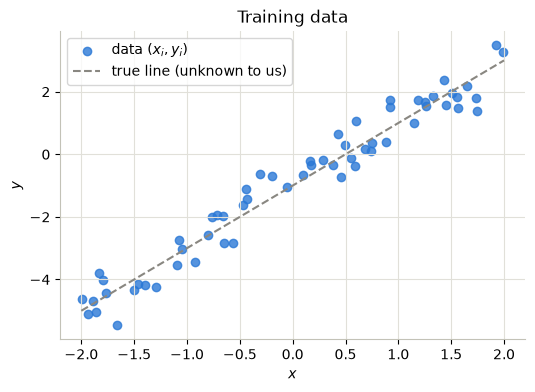

In [2]:
# Ground truth: y = 2x - 1 + noise
w_true, b_true = 2.0, -1.0
n = 60
x = rng.uniform(-2, 2, size=n)
y = w_true * x + b_true + 0.5 * rng.standard_normal(n)

plt.scatter(x, y, color=BLUE, alpha=0.8, label="data $(x_i, y_i)$")
plt.plot([-2, 2], [w_true * -2 + b_true, w_true * 2 + b_true],
         color="#898781", ls="--", label="true line (unknown to us)")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(); plt.title("Training data")
plt.show()

### The exact solution

Linear regression is special: $L(w,b)$ is a **convex quadratic**, so we can solve $\nabla L = 0$ in closed form. Stacking the data as $X = \begin{pmatrix} x_1 & 1 \\ \vdots & \vdots \\ x_n & 1\end{pmatrix}$ and $\theta = (w, b)^\top$, the MSE is $L(\theta) = \tfrac1n \lVert X\theta - y \rVert^2$ and setting the gradient to zero gives the **normal equations**:

$$X^\top X \, \hat\theta = X^\top y \quad\Longrightarrow\quad \hat\theta = (X^\top X)^{-1} X^\top y.$$

closed form:  w = 1.992,  b = -0.957   (true: w = 2, b = -1)


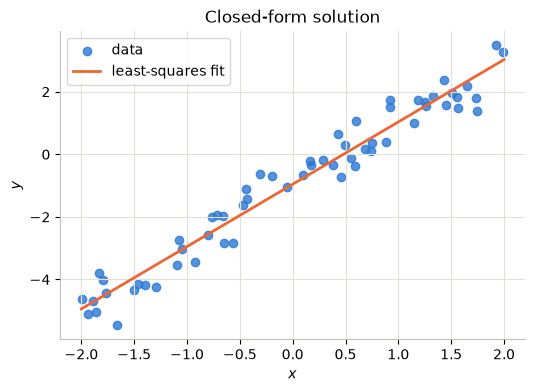

In [3]:
X = np.stack([x, np.ones(n)], axis=1)          # design matrix, shape (n, 2)
theta_hat = np.linalg.solve(X.T @ X, X.T @ y)  # solve the normal equations
w_hat, b_hat = theta_hat
print(f"closed form:  w = {w_hat:.3f},  b = {b_hat:.3f}   (true: w = 2, b = -1)")

xs = np.linspace(-2, 2, 100)
plt.scatter(x, y, color=BLUE, alpha=0.8, label="data")
plt.plot(xs, w_hat * xs + b_hat, color=ORANGE, lw=2, label="least-squares fit")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(); plt.title("Closed-form solution")
plt.show()

## 3. Gradient descent

For neural networks there is no closed-form solution — but we can always follow the negative gradient downhill. **Gradient descent (GD)** iterates

$$\theta_{k+1} = \theta_k - \eta \, \nabla L(\theta_k),$$

where $\eta > 0$ is the **learning rate** (step size). The gradient points in the direction of steepest *ascent*, so $-\nabla L$ is the direction of steepest *descent*; for small enough $\eta$ each step decreases the loss.

For our linear model the gradient can be computed by hand:

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^n \big(w x_i + b - y_i\big)\, x_i,
\qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^n \big(w x_i + b - y_i\big).$$

In [4]:
def loss(w, b):
    return np.mean((w * x + b - y) ** 2)

def gradient(w, b):
    r = w * x + b - y                      # residuals
    return 2 * np.mean(r * x), 2 * np.mean(r)

# Gradient descent, starting far from the optimum
eta, steps = 0.1, 60
w, b = -1.5, 2.0
path = [(w, b, loss(w, b))]
for k in range(steps):
    gw, gb = gradient(w, b)
    w, b = w - eta * gw, b - eta * gb
    path.append((w, b, loss(w, b)))
path = np.array(path)

print(f"gradient descent:  w = {w:.3f},  b = {b:.3f}")
print(f"closed form:       w = {w_hat:.3f},  b = {b_hat:.3f}")

gradient descent:  w = 1.992,  b = -0.957
closed form:       w = 1.992,  b = -0.957


GD converges to the same solution as the normal equations. Because we have only two parameters, we can *see* the optimization: the loss $L(w, b)$ is a surface over the $(w, b)$-plane, and GD walks downhill on it.

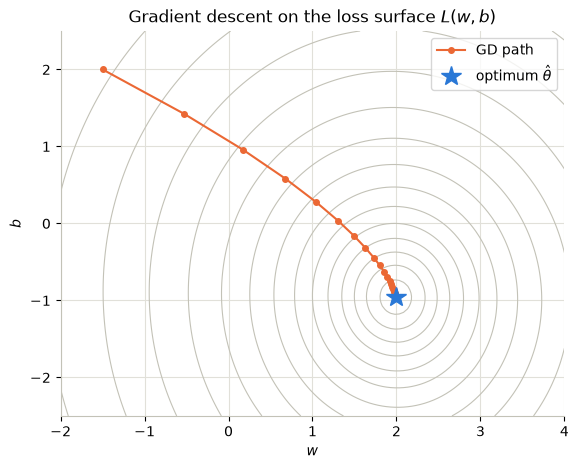

In [5]:
# Loss landscape over the (w, b) plane
W, B = np.meshgrid(np.linspace(-2, 4, 120), np.linspace(-2.5, 2.5, 120))
Z = np.array([[loss(wi, bi) for wi in W[0]] for bi in B[:, 0]])

fig, ax = plt.subplots(figsize=(6.5, 5))
cs = ax.contour(W, B, Z, levels=np.geomspace(Z.min() + 0.05, Z.max(), 15),
                colors="#c3c2b7", linewidths=0.8)
ax.plot(path[:, 0], path[:, 1], "o-", color=ORANGE, ms=4, lw=1.5, label="GD path")
ax.plot(w_hat, b_hat, "*", color=BLUE, ms=15, label=r"optimum $\hat\theta$")
ax.set_xlabel("$w$"); ax.set_ylabel("$b$"); ax.legend()
ax.set_title(r"Gradient descent on the loss surface $L(w,b)$")
plt.show()

### Animation: watching gradient descent

The same picture, animated step by step. Note how the steps are large at first (steep slope ⇒ large gradient) and shrink as we approach the minimum, where $\nabla L \to 0$.

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.8), dpi=75)
ax.contour(W, B, Z, levels=np.geomspace(Z.min() + 0.05, Z.max(), 15),
           colors="#c3c2b7", linewidths=0.8)
ax.plot(w_hat, b_hat, "*", color=BLUE, ms=14)
ax.set_xlabel("$w$"); ax.set_ylabel("$b$")
trail, = ax.plot([], [], "-", color=ORANGE, lw=1.5)
point, = ax.plot([], [], "o", color=ORANGE, ms=7)
title = ax.set_title("")

show_steps = list(range(0, 20)) + list(range(20, len(path), 4))  # early steps matter most

def update(i):
    k = show_steps[i]
    trail.set_data(path[:k + 1, 0], path[:k + 1, 1])
    point.set_data([path[k, 0]], [path[k, 1]])
    title.set_text(f"step {k}:  L = {path[k, 2]:.3f}")
    return trail, point, title

anim = animation.FuncAnimation(fig, update, frames=len(show_steps), interval=150, blit=False)
plt.close(fig)                      # avoid showing the static figure twice
HTML(anim.to_jshtml())

### The learning rate matters

The step size $\eta$ is the most important **hyperparameter** in deep learning. For a quadratic loss one can show that GD converges if and only if $\eta < 2/\lambda_{\max}$, where $\lambda_{\max}$ is the largest eigenvalue of the Hessian $\nabla^2 L$. In practice:

- $\eta$ **too small** → convergence is painfully slow,
- $\eta$ **too large** → the iterates overshoot and oscillate, or even **diverge**.

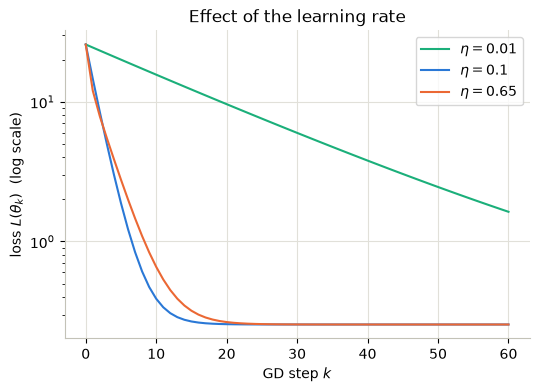

In [7]:
fig, ax = plt.subplots()
for eta_try, color in [(0.01, AQUA), (0.1, BLUE), (0.65, ORANGE)]:
    w, b = -1.5, 2.0
    losses = [loss(w, b)]
    for k in range(60):
        gw, gb = gradient(w, b)
        w, b = w - eta_try * gw, b - eta_try * gb
        losses.append(loss(w, b))
    ax.semilogy(losses, color=color, label=rf"$\eta = {eta_try}$")
ax.set_xlabel("GD step $k$"); ax.set_ylabel(r"loss $L(\theta_k)$  (log scale)")
ax.legend(); ax.set_title("Effect of the learning rate")
plt.show()

## 4. Automatic differentiation

We computed $\nabla L$ by hand — hopeless for a network with millions of parameters. **Automatic differentiation (autodiff)** solves this: it computes *exact* gradients (up to floating point) of any function built from differentiable operations, at roughly the cost of one extra function evaluation.

The idea: every computation is a **graph** of elementary operations, and the chain rule composes their derivatives. For $L = g(h(\theta))$:

$$\frac{\partial L}{\partial \theta} = \frac{\partial g}{\partial h} \cdot \frac{\partial h}{\partial \theta}.$$

**Reverse-mode** autodiff (a.k.a. **backpropagation**) traverses the graph from the output backwards, accumulating these products. One backward pass yields $\partial L / \partial \theta_j$ for **all** parameters $\theta_j$ simultaneously — this is why training huge networks is feasible at all.

In PyTorch: mark a tensor with `requires_grad=True`, compute, then call `.backward()`.

In [8]:
# f(x) = sin(x^2) * exp(-x);   analytic derivative: f'(x) = (2x cos(x^2) - sin(x^2)) e^{-x}
x0 = torch.tensor(1.3, requires_grad=True)

f = torch.sin(x0 ** 2) * torch.exp(-x0)   # forward pass (builds the graph)
f.backward()                              # backward pass (chain rule)

analytic = (2 * x0 * torch.cos(x0 ** 2) - torch.sin(x0 ** 2)) * torch.exp(-x0)
h = 1e-5                                  # finite differences, for comparison
def f_np(t): return np.sin(t ** 2) * np.exp(-t)
finite_diff = (f_np(1.3 + h) - f_np(1.3 - h)) / (2 * h)

print(f"autograd:           {x0.grad.item():.10f}")
print(f"analytic:           {analytic.item():.10f}")
print(f"finite differences: {finite_diff:.10f}")

autograd:           -0.3548634648
analytic:           -0.3548634648
finite differences: -0.3548635744


Autodiff is **not** numerical differentiation (no step size $h$, no truncation error) and **not** symbolic differentiation (no expression swell) — it evaluates the chain rule numerically on the graph.

Let's redo linear regression, but now PyTorch computes the gradients:

In [9]:
xt, yt = torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

theta = torch.tensor([-1.5, 2.0], requires_grad=True)   # (w, b), same start as before
eta = 0.1
for k in range(60):
    L = torch.mean((theta[0] * xt + theta[1] - yt) ** 2)
    L.backward()                       # theta.grad now holds dL/dtheta
    with torch.no_grad():              # the update itself is not differentiated
        theta -= eta * theta.grad
    theta.grad.zero_()                 # gradients accumulate -> reset each step

print(f"autograd GD:  w = {theta[0]:.3f},  b = {theta[1]:.3f}")
print(f"closed form:  w = {w_hat:.3f},  b = {b_hat:.3f}")

autograd GD:  w = 1.992,  b = -0.957
closed form:  w = 1.992,  b = -0.957


## 5. Neural networks

Linear models can only represent linear relationships. A **neural network** stacks affine maps with elementwise nonlinearities. The simplest case, a **multilayer perceptron (MLP)** with one hidden layer of width $m$:

$$f_\theta(x) \;=\; W_2 \,\sigma\!\big(W_1 x + b_1\big) + b_2,
\qquad \theta = (W_1, b_1, W_2, b_2),$$

where $\sigma$ is an **activation function** applied componentwise. Without $\sigma$ the composition of affine maps would collapse to a single affine map — the nonlinearity is what buys expressiveness.

**Universal approximation theorem** (Cybenko 1989, Hornik 1991, informal): for any continuous $g$ on a compact set and any $\varepsilon > 0$, there is a one-hidden-layer network $f_\theta$ with $\lVert f_\theta - g \rVert_\infty < \varepsilon$, provided the width $m$ is large enough. The theorem says such weights *exist* — finding them means minimizing the loss function, which we attack with gradient descent.

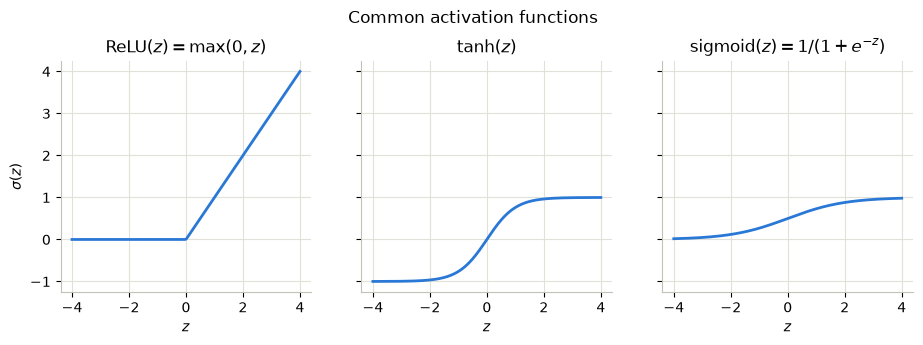

In [10]:
z = torch.linspace(-4, 4, 200)
fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, fn, name in [(axes[0], torch.relu, "ReLU$(z) = \\max(0, z)$"),
                     (axes[1], torch.tanh, "tanh$(z)$"),
                     (axes[2], torch.sigmoid, "sigmoid$(z) = 1/(1+e^{-z})$")]:
    ax.plot(z, fn(z), color=BLUE, lw=2)
    ax.set_title(name); ax.set_xlabel("$z$")
axes[0].set_ylabel(r"$\sigma(z)$")
fig.suptitle("Common activation functions", y=1.05)
plt.show()

### Fitting a nonlinear function

Target: $g(x) = \sin(2\pi x)$ on $[-1, 1]$, observed with noise. We build a small MLP with `nn.Sequential` and train it with the loop that *every* PyTorch training script follows:

```
for each step:  forward pass → loss → zero grads → backward pass → optimizer step
```

Instead of plain GD we use **Adam**, a variant with per-parameter adaptive step sizes (more on optimizers in notebook 04).

In [11]:
# Noisy samples of g(x) = sin(2*pi*x)
n_reg = 80
x_reg = rng.uniform(-1, 1, size=(n_reg, 1))
y_reg = np.sin(2 * np.pi * x_reg) + 0.1 * rng.standard_normal((n_reg, 1))
xt_reg = torch.tensor(x_reg, dtype=torch.float32)
yt_reg = torch.tensor(y_reg, dtype=torch.float32)

model = nn.Sequential(          # 1 -> 32 -> 32 -> 1 MLP
    nn.Linear(1, 32), nn.Tanh(),
    nn.Linear(32, 32), nn.Tanh(),
    nn.Linear(32, 1),
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

xs = torch.linspace(-1, 1, 200).reshape(-1, 1)
snapshots = {}                       # model predictions at a few checkpoints
for epoch in range(2001):
    y_pred = model(xt_reg)           # forward pass
    L = loss_fn(y_pred, yt_reg)      # training loss
    optimizer.zero_grad()            # reset accumulated gradients
    L.backward()                     # backprop
    optimizer.step()                 # parameter update
    if epoch in (0, 100, 500, 2000):
        with torch.no_grad():
            snapshots[epoch] = model(xs).numpy()
        print(f"epoch {epoch:4d}:  MSE = {L.item():.4f}")

epoch    0:  MSE = 0.5755
epoch  100:  MSE = 0.2959


epoch  500:  MSE = 0.0092


epoch 2000:  MSE = 0.0089


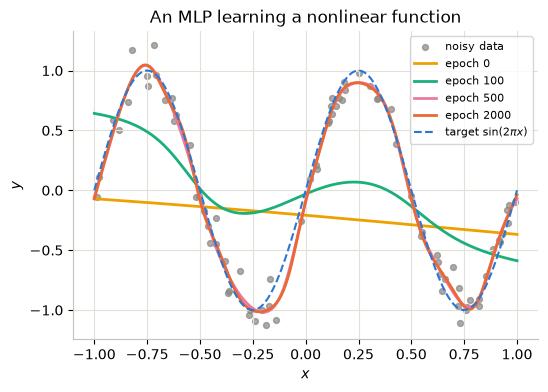

In [12]:
plt.scatter(x_reg, y_reg, color="#898781", s=18, alpha=0.7, label="noisy data")
for (epoch, pred), color in zip(snapshots.items(), [YELLOW, AQUA, MAGENTA, ORANGE]):
    plt.plot(xs, pred, color=color, lw=2, label=f"epoch {epoch}")
plt.plot(xs, np.sin(2 * np.pi * xs.numpy()), color=BLUE, ls="--", label=r"target $\sin(2\pi x)$")
plt.xlabel("$x$"); plt.ylabel("$y$"); plt.legend(fontsize=8)
plt.title("An MLP learning a nonlinear function")
plt.show()

## 6. Generalization: train / test splits

Training minimizes the loss **on the training data** — but what we care about is the risk on **new** data. The gap

$$R(\hat f) - L(\hat f)$$

is the **generalization gap**. A model can drive the training loss to zero simply by *memorizing* the data (fitting the noise), while performing terribly on new samples: this is **overfitting**. The opposite failure — an ansatz too weak to capture the signal — is **underfitting**.

Since $P$ is unknown, we *estimate* the risk by holding out a **test set** that the training procedure never sees:

$$R(\hat f) \;\approx\; \frac{1}{n_{\text{test}}} \sum_{i \in \text{test}} \ell\big(\hat f(x_i), y_i\big).$$

The classic demonstration uses polynomial regression: fit polynomials $f(x) = \sum_{j=0}^{d} \theta_j x^j$ of increasing degree $d$ (this is still *linear* in $\theta$, so least squares applies).

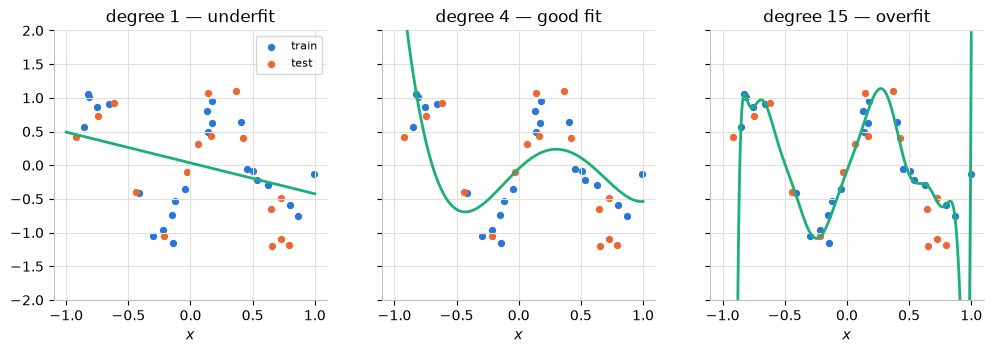

In [13]:
# Noisy samples of a smooth function, split into train and test
n_all = 40
x_all = np.sort(rng.uniform(-1, 1, n_all))
y_all = np.sin(2 * np.pi * x_all) + 0.25 * rng.standard_normal(n_all)
idx = rng.permutation(n_all)
train, test = idx[:24], idx[24:]     # 60% train / 40% test

def polyfit(deg):                    # least squares on the training split
    return np.polynomial.Polynomial.fit(x_all[train], y_all[train], deg)

xs = np.linspace(-1, 1, 300)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, deg, label in zip(axes, [1, 4, 15], ["underfit", "good fit", "overfit"]):
    p = polyfit(deg)
    ax.scatter(x_all[train], y_all[train], color=BLUE, s=18, label="train")
    ax.scatter(x_all[test], y_all[test], color=ORANGE, s=18, label="test")
    ax.plot(xs, p(xs), color=AQUA, lw=2)
    ax.set_ylim(-2, 2); ax.set_title(f"degree {deg} — {label}"); ax.set_xlabel("$x$")
axes[0].legend(fontsize=8)
plt.show()

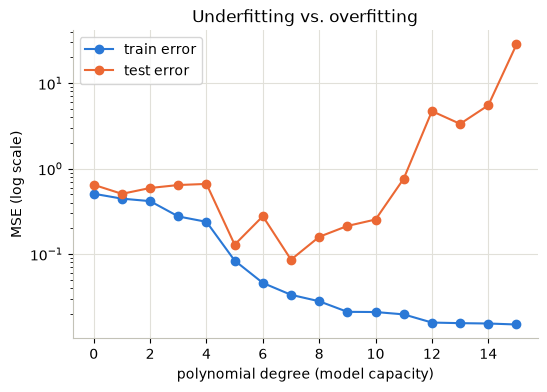

In [14]:
degrees = np.arange(0, 16)
train_err, test_err = [], []
for d in degrees:
    p = polyfit(d)
    train_err.append(np.mean((p(x_all[train]) - y_all[train]) ** 2))
    test_err.append(np.mean((p(x_all[test]) - y_all[test]) ** 2))

plt.semilogy(degrees, train_err, "o-", color=BLUE, label="train error")
plt.semilogy(degrees, test_err, "o-", color=ORANGE, label="test error")
plt.xlabel("polynomial degree (model capacity)"); plt.ylabel("MSE (log scale)")
plt.legend(); plt.title("Underfitting vs. overfitting")
plt.show()

The signature picture of classical learning theory: **training error decreases monotonically** with capacity, while **test error is U-shaped** — first the model captures signal (both errors drop), then it starts fitting noise (test error climbs). We choose the model with the best *test* performance, never the best training performance.

> In practice one uses *three* splits — train / **validation** / test — tuning hyperparameters on the validation set and touching the test set only once, at the very end.

## 7. Putting it all together: a classifier

Finally, a complete deep learning pipeline on a **binary classification** task — the "two moons" dataset, which no linear model can separate.

**Model.** The network outputs *logits* $z = f_\theta(x) \in \mathbb{R}^2$, turned into class probabilities by the **softmax**: $\;p_c = e^{z_c} / \sum_{c'} e^{z_{c'}}$.

**Loss.** The **cross-entropy** is the negative log-likelihood of the true class:

$$\ell(z, y) = -\log p_y = -z_y + \log \sum_{c} e^{z_c}.$$

Minimizing it is exactly maximum likelihood estimation.

**Optimization.** With large datasets, computing $\nabla \widehat R$ over *all* $n$ points per step is wasteful. **Stochastic gradient descent (SGD)** uses a random **mini-batch** $B \subset \{1,\dots,n\}$ per step:

$$\theta_{k+1} = \theta_k - \eta \cdot \frac{1}{|B|} \sum_{i \in B} \nabla_\theta\, \ell\big(f_\theta(x_i), y_i\big),$$

an *unbiased* estimate of the full gradient that is much cheaper — this is what PyTorch's `DataLoader` is for.

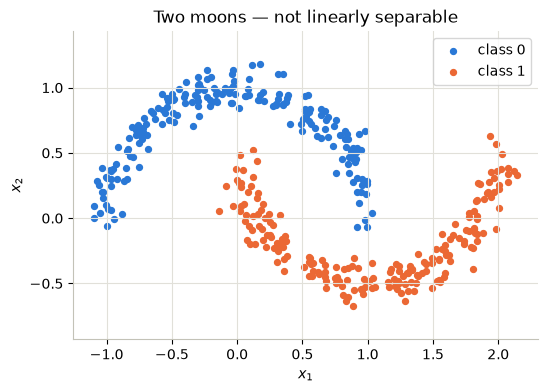

In [15]:
def make_moons(n_per_class=200, noise=0.08):
    t = np.pi * rng.random(n_per_class)
    upper = np.stack([np.cos(t), np.sin(t)], axis=1)             # class 0
    lower = np.stack([1 - np.cos(t), 0.5 - np.sin(t)], axis=1)   # class 1
    X = np.concatenate([upper, lower]) + noise * rng.standard_normal((2 * n_per_class, 2))
    y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).astype(np.int64)
    return X.astype(np.float32), y

X_moons, y_moons = make_moons()
perm = rng.permutation(len(X_moons))
tr, te = perm[:300], perm[300:]      # 75% train / 25% test

plt.scatter(*X_moons[y_moons == 0].T, color=BLUE, s=18, label="class 0")
plt.scatter(*X_moons[y_moons == 1].T, color=ORANGE, s=18, label="class 1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.axis("equal")
plt.title("Two moons — not linearly separable")
plt.show()

In [16]:
from torch.utils.data import DataLoader, TensorDataset

train_set = TensorDataset(torch.tensor(X_moons[tr]), torch.tensor(y_moons[tr]))
loader = DataLoader(train_set, batch_size=32, shuffle=True)
X_test, y_test = torch.tensor(X_moons[te]), torch.tensor(y_moons[te])

clf = nn.Sequential(                 # 2 -> 16 -> 16 -> 2 (logits)
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 16), nn.ReLU(),
    nn.Linear(16, 2),
)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()      # softmax + negative log-likelihood in one

# Grid on which we will visualize the decision boundary
g1, g2 = np.meshgrid(np.linspace(-1.8, 2.8, 120), np.linspace(-1.3, 1.8, 120))
grid = torch.tensor(np.stack([g1.ravel(), g2.ravel()], axis=1), dtype=torch.float32)

history, frames = [], []
for epoch in range(80):
    for xb, yb in loader:            # one pass over the mini-batches = one epoch
        L = loss_fn(clf(xb), yb)
        optimizer.zero_grad()
        L.backward()
        optimizer.step()
    with torch.no_grad():            # evaluate on held-out data (no gradients needed)
        test_acc = (clf(X_test).argmax(dim=1) == y_test).float().mean().item()
        history.append((L.item(), test_acc))
        if epoch % 4 == 0:           # snapshot P(class 1) on the grid for the animation
            probs = torch.softmax(clf(grid), dim=1)[:, 1].reshape(g1.shape).numpy()
            frames.append((epoch, probs))

print(f"final test accuracy: {history[-1][1]:.1%}")

final test accuracy: 100.0%


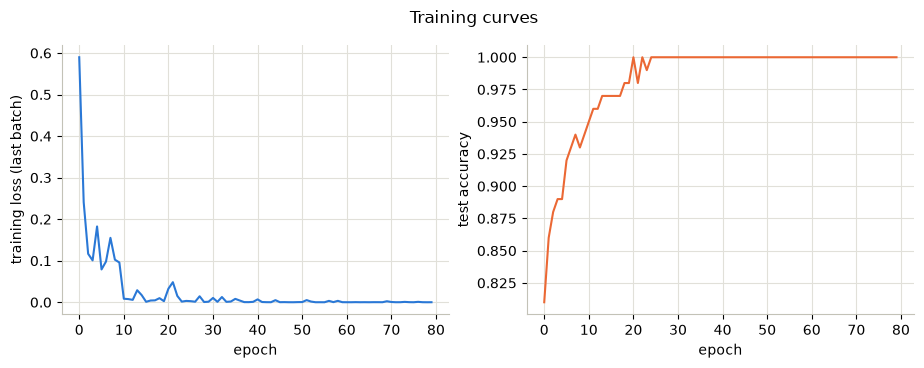

In [17]:
history_arr = np.array(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(history_arr[:, 0], color=BLUE)
ax1.set_xlabel("epoch"); ax1.set_ylabel("training loss (last batch)")
ax2.plot(history_arr[:, 1], color=ORANGE)
ax2.set_xlabel("epoch"); ax2.set_ylabel("test accuracy")
fig.suptitle("Training curves")
plt.show()

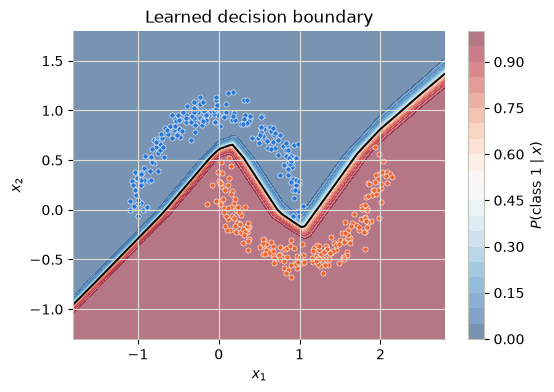

In [18]:
with torch.no_grad():
    probs = torch.softmax(clf(grid), dim=1)[:, 1].reshape(g1.shape).numpy()

plt.contourf(g1, g2, probs, levels=20, cmap="RdBu_r", alpha=0.55, vmin=0, vmax=1)
plt.colorbar(label=r"$P(\mathrm{class}\ 1 \mid x)$")
plt.contour(g1, g2, probs, levels=[0.5], colors="#0b0b0b", linewidths=1.5)
plt.scatter(*X_moons[y_moons == 0].T, color=BLUE, s=14, edgecolors="white", lw=0.4)
plt.scatter(*X_moons[y_moons == 1].T, color=ORANGE, s=14, edgecolors="white", lw=0.4)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("Learned decision boundary")
plt.show()

### Animation: the decision boundary during training

The network starts with an essentially random (near-linear) boundary and gradually bends it around the moons as SGD reduces the cross-entropy.

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 4))

def draw(i):
    epoch, probs = frames[i]
    ax.clear()
    ax.contourf(g1, g2, probs, levels=20, cmap="RdBu_r", alpha=0.55, vmin=0, vmax=1)
    ax.contour(g1, g2, probs, levels=[0.5], colors="#0b0b0b", linewidths=1.5)
    ax.scatter(*X_moons[y_moons == 0].T, color=BLUE, s=10)
    ax.scatter(*X_moons[y_moons == 1].T, color=ORANGE, s=10)
    ax.set_title(f"epoch {epoch}")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

anim = animation.FuncAnimation(fig, draw, frames=len(frames), interval=250)
plt.close(fig)
HTML(anim.to_jshtml())

## Summary

| Concept | Key formula / idea |
|---|---|
| Supervised learning | learn $f$ from samples $(x_i, y_i) \sim P$ |
| Loss minimization | $\min_{f\in\mathcal F} \frac1n \sum_i \ell(f(x_i), y_i)$ |
| Gradient descent | $\theta_{k+1} = \theta_k - \eta\, \nabla L(\theta_k)$ |
| Backpropagation | reverse-mode autodiff: all gradients in one backward pass |
| Neural network (MLP) | $W_2\, \sigma(W_1 x + b_1) + b_2$ — universal approximator |
| Generalization | evaluate on held-out data; watch for the U-shaped test error |
| SGD + mini-batches | cheap unbiased gradient estimates via `DataLoader` |
| Training loop | forward → loss → `zero_grad()` → `backward()` → `step()` |

### Exercises

1. **Learning rate.** In Section 3, find (numerically) the largest $\eta$ for which GD still converges. Compare with the theoretical bound $2/\lambda_{\max}(\nabla^2 L)$ — compute the Hessian of the quadratic loss by hand ($\nabla^2 L = \tfrac{2}{n} X^\top X$).
2. **Autodiff.** Use `torch.autograd` to differentiate $f(x) = \log(1 + e^{x})$ at $x = 100$. Explain the result (hint: numerical stability), and compare with `torch.nn.functional.softplus`.
3. **Capacity.** Repeat the two-moons experiment with hidden widths 2, 4, and 64. Plot the three decision boundaries. Which underfits?
4. **Early stopping.** In Section 6, fix the degree at 15 but fit with gradient descent instead of least squares, recording train/test error per iteration. What do you observe about the test error over time?
5. **Regularization.** Add the penalty $\lambda \lVert \theta \rVert^2$ to the degree-15 polynomial loss (this is *ridge regression*: $\hat\theta = (X^\top X + \lambda I)^{-1} X^\top y$). Sweep $\lambda$ and plot the train/test errors. How does it relate to Exercise 4?

**Next notebook:** `02_neuralodes.ipynb` — neural networks as continuous-time dynamical systems.